<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
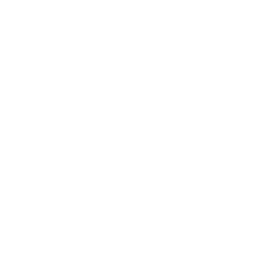
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Solar Generation Seasonal Forecast</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Renewable Asset Management &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

We model **monthly photovoltaic generation** for a 50 MW single-axis-tracking solar array (SOLAR-FARM-ALPHA) over 100 months (January 2017 through April 2025) using an unobserved components model (PROC UCM). The model decomposes generation into a slowly moving **level**, a **slope** that captures gradual panel degradation, a **trigonometric seasonal** term (`TYPE=TRIG`, `LENGTH=12`) for the smooth annual irradiance cycle, and an **irregular** term for weather-driven scatter.

Fitting on 100 observations yields a log likelihood of **-685.12** (AIC **1378.23**, BIC **1388.65**). The irregular variance dominates (sigma-squared = 285,883, a roughly 535 MWh month-to-month weather standard deviation), while the slope variance is small (5.58), consistent with a steady, near-deterministic degradation trend rather than abrupt panel failure. The 12-month-ahead forecast (May 2025 - April 2026) tracks the established seasonal shape, peaking at **11,713 MWh** in July 2025 and bottoming at **3,536 MWh** in January 2026. Summed over the horizon, projected generation is **91,921 MWh**, clearing the 85,000 MWh power-purchase-agreement (PPA) minimum with a **6,921 MWh (8.1%) buffer**.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.SOLAR_MONTHLY | Monthly generation output (MWh) | 100 |
| WORK.PANEL_SPECS | Solar array technical specifications | 10 |

The generation series is synthetic but calibrated to a realistic utility-scale profile: an average capacity factor near 0.21, a summer-peaking annual cycle, and a slow degradation drift over the 8.3-year window. The unlicensed engine caps input at 100 observations, so we model at **monthly** resolution (100 months with a `LENGTH=12` annual season) rather than daily.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly solar generation data:
   100 months (~8.3 years) for a 50 MW utility-scale array.
   Capacity factor ~0.21 with a summer-peaking annual cycle
   and a gradual panel-degradation drift.
   -------------------------------------------------------- */
data work.solar_monthly;
    call streaminit(42);
    array_id = 'SOLAR-FARM-ALPHA';
    nameplate_mw = 50;
    do mon_seq = 1 to 100;
        gen_date = intnx('month', '01JAN2017'd, mon_seq - 1);
        month_of_year = month(gen_date);
        /* gradual degradation across the observation window */
        degrade_factor = 1.0 - (mon_seq / 100) * 0.04;
        /* annual irradiance cycle: summer peak, winter trough */
        seasonal_cf = 0.22 + 0.12 *
            sin(2 * constant('pi') * (month_of_year - 4) / 12);
        days_in_month = intnx('month', gen_date, 1) - gen_date;
        cap_factor = seasonal_cf * degrade_factor;
        base_gen = nameplate_mw * cap_factor * 24 * days_in_month;
        /* weather noise: clouds, storms */
        noise = 1.0 + rand('normal', 0, 0.06);
        monthly_gen_mwh = round(base_gen * noise, 1);
        if monthly_gen_mwh < 0 then monthly_gen_mwh = 0;
        capacity_util = round(monthly_gen_mwh /
            (nameplate_mw * 24 * days_in_month), 0.001);
        output;
    end;
    keep array_id gen_date mon_seq monthly_gen_mwh capacity_util;
    format gen_date date9.;
run;

NOTE: DATA work.solar_monthly


NOTE: Wrote work.solar_monthly (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Solar array specifications reference
   -------------------------------------------------------- */
data work.panel_specs;
    length spec_name $30 spec_value $40;
    array_id = 'SOLAR-FARM-ALPHA';
    spec_name = 'Nameplate Capacity'; spec_value = '50 MW'; output;
    spec_name = 'Panel Type'; spec_value = 'Monocrystalline Si'; output;
    spec_name = 'Installation Date'; spec_value = '01JAN2017'; output;
    spec_name = 'Tilt Angle'; spec_value = '30 degrees'; output;
    spec_name = 'Tracking'; spec_value = 'Single-Axis'; output;
    spec_name = 'Inverter Rating'; spec_value = '52 MW AC'; output;
    spec_name = 'Warranty Period'; spec_value = '25 years'; output;
    spec_name = 'Expected Degradation'; spec_value = '0.5% per year'; output;
    spec_name = 'PPA Price'; spec_value = '$42/MWh'; output;
    spec_name = 'PPA Minimum Annual'; spec_value = '85,000 MWh'; output;
run;

NOTE: DATA work.panel_specs


NOTE: Wrote work.panel_specs (10 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### Baseline generation profile

Summary statistics and the raw monthly series establish the scale and the seasonal swing the model must capture.

                                      Baseline Monthly Solar Generation Statistics                                      

                                                  The MEANS Procedure

 Variable                N           Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------
 MONTHLY_GEN_MWH       100         7741.1      3061.5      3253.0     13231.0
 CAPACITY_UTIL         100            0.2         0.1         0.1         0.4
 ----------------------------------------------------------------------------

                                      Baseline Monthly Solar Generation Statistics                                      



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=860px, height=420px, format=SVG).
NOTE: PROC SGPLOT data=work.solar_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


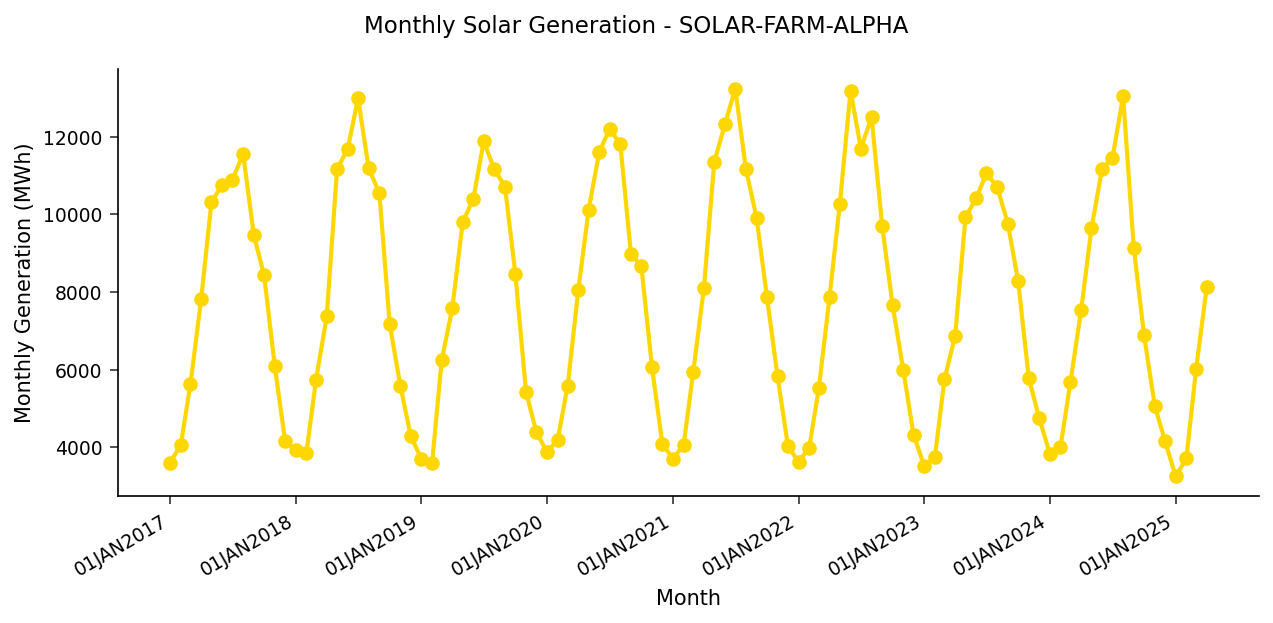

In [3]:
/* --------------------------------------------------------
   Baseline generation statistics
   -------------------------------------------------------- */
proc means data=work.solar_monthly n mean std min max maxdec=1;
    var monthly_gen_mwh capacity_util;
    title 'Baseline Monthly Solar Generation Statistics';
run;

ods graphics on / imagefmt=svg width=860 height=420;

proc sgplot data=work.solar_monthly;
    series x=gen_date y=monthly_gen_mwh /
        lineattrs=(thickness=2 color=gold) markers
        markerattrs=(symbol=circlefilled size=5 color=darkorange);
    xaxis label='Month';
    yaxis label='Monthly Generation (MWh)';
    title 'Monthly Solar Generation - SOLAR-FARM-ALPHA';
run;

Mean monthly output is **7,741 MWh** (standard deviation **3,061 MWh**), ranging from a winter low of **3,253 MWh** to a summer high of **13,231 MWh**. The average capacity factor is **0.212** (range 0.087 to 0.366) — a realistic figure for a single-axis-tracking array. The plot shows eight clean annual cycles, the signal the UCM seasonal component will isolate.

---

### Unobserved components model

PROC UCM fits the level, slope (degradation), trigonometric annual season, and irregular components, then forecasts 12 months ahead. The procedure also renders a component-decomposition panel, a forecast plot, and residual diagnostics.

                                      Baseline Monthly Solar Generation Statistics                                      


                 The UCM Procedure

  Dependent Variable: monthly_gen_mwh
  Time ID Variable: gen_date
  Interval: month
  Number of Observations: 100

  Component Variances:
  Component          Estimate      Std Error
  -----------        ----------    ----------
  sigma2.irregular   285883.1191    54658.3782
  sigma2.level        3437.1512     6347.5479
  sigma2.trend           5.5794       14.8314
  sigma2.slope           5.5794       14.8314
  sigma2.freq_seasonal_12(6)     0.0306      254.4255

  Level Component:

  Slope Component:

  Irregular Component:

  Season Component:
    Length: 12 (length=12 season)
    Type: trig

  Fit Statistics:
    AIC: 1378.2336
    BIC: 1388.6543
    Log Likelihood: -685.1168

  Forecasts:
  Obs    Forecast      StdErr       Lower        Upper
  ---    --------      ------       -----        -----
  1      10135.6573    606.

NOTE: PROC UCM data=work.solar_monthly

NOTE: Using Python statsmodels version 0.14.6
NOTE: OUTFOR dataset work.solar_forecast created with 112 observations.
NOTE: ODS plot written: ucm_components.spec.json
NOTE: ODS plot written: ucm_forecast.spec.json
NOTE: ODS plot written: ucm_diagnostics.spec.json
NOTE: Processed 100 rows.


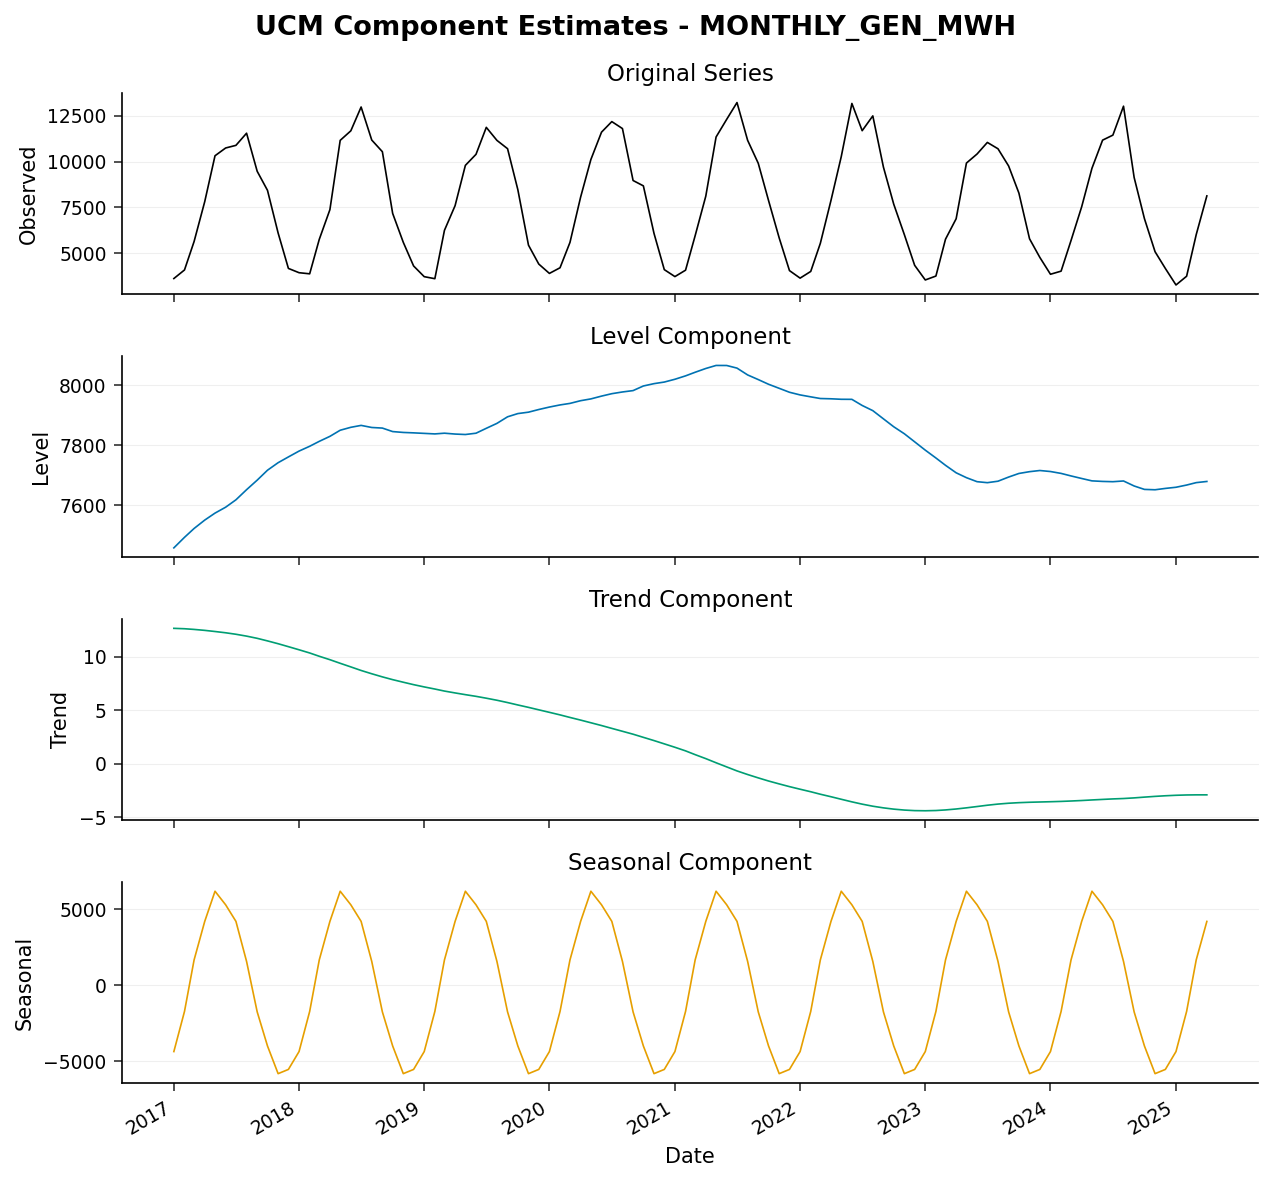

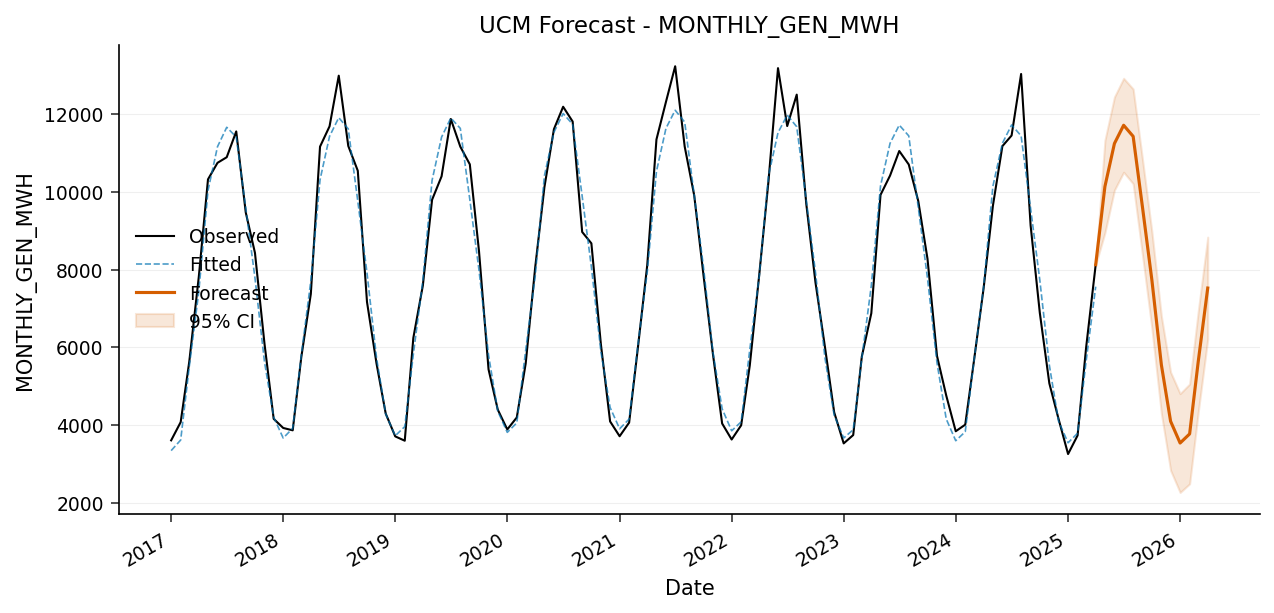

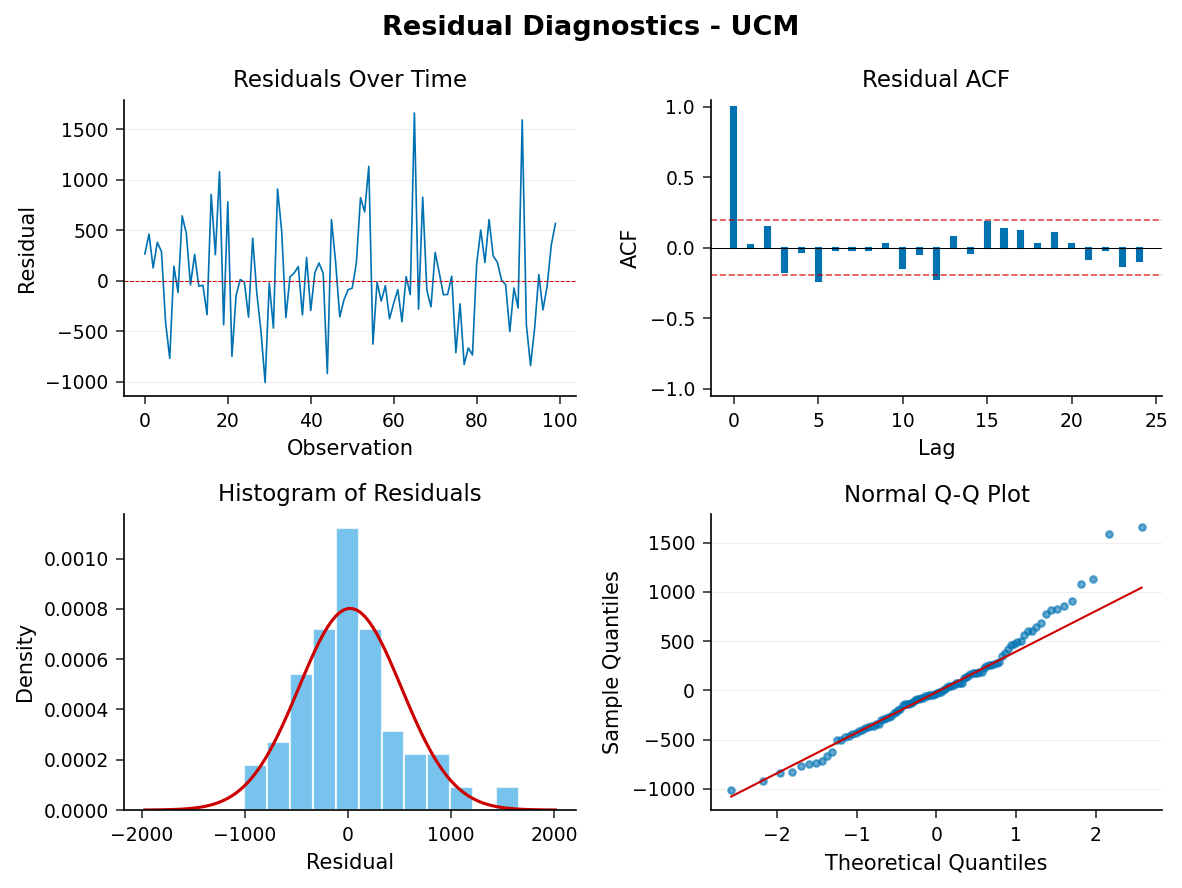

In [4]:
/* --------------------------------------------------------
   PROC UCM: monthly solar generation with a trigonometric
   annual season and a local linear trend for panel-
   degradation detection. Forecast 12 months ahead.
   -------------------------------------------------------- */
proc ucm data=work.solar_monthly;
    id gen_date interval=month;
    model monthly_gen_mwh;
    level;
    slope;
    season length=12 type=trig;
    irregular;
    estimate;
    forecast lead=12 outfor=work.solar_forecast;
run;

The component-variance estimates summarise where the variation lives. The **irregular** variance is by far the largest (sigma-squared = 285,883, about a 535 MWh standard deviation), capturing month-to-month weather scatter. The **level** variance is 3,437 and the **slope/trend** variance is just 5.58 — a small, smooth degradation drift consistent with the warranty expectation of about 0.5% per year, with no sign of abrupt panel failure. The fit summary reports AIC **1378.23**, BIC **1388.65**, and log likelihood **-685.12**.

The **Component Estimates** panel separates the smooth level, the declining trend contribution, and the +/- 5,000-6,000 MWh annual seasonal swing. The **Forecast** panel extends the fitted series 12 months with a 95% confidence band, and the **Residual Diagnostics** panel confirms the residuals are close to white noise (autocorrelations within their bands, an approximately normal Q-Q plot).

---

### PPA compliance check

We isolate the 12 forecast (out-of-sample) rows — those with a missing observed value — and aggregate the point forecast and its confidence bounds to a projected annual total, then compare against the 85,000 MWh PPA minimum.

In [5]:
/* --------------------------------------------------------
   Isolate the 12-month forecast horizon (forecast rows have
   a missing observed value) and aggregate to an annual total.
   -------------------------------------------------------- */
data work.forecast_future;
    set work.solar_forecast;
    where monthly_gen_mwh = .;
    /* OUTFOR stores the date as a character serial; parse it back
       to a numeric SAS date for a readable MON-YYYY label. */
    gen_date_num = input(gen_date, best12.);
    forecast_month = put(gen_date_num, monyy7.);
    keep gen_date forecast_month forecast lcl ucl;
run;

proc print data=work.forecast_future noobs;
    var forecast_month forecast lcl ucl;
    format forecast lcl ucl comma10.0;
    title 'Projected Monthly Generation (12-Month Horizon)';
run;

proc means data=work.forecast_future sum maxdec=0;
    var forecast lcl ucl;
    output out=work.annual_sum(drop=_type_ _freq_)
        sum=annual_forecast_mwh annual_lcl_mwh annual_ucl_mwh;
    title 'Projected 12-Month Total vs PPA Minimum (85,000 MWh)';
run;

proc print data=work.annual_sum noobs;
    format annual_forecast_mwh annual_lcl_mwh annual_ucl_mwh comma12.0;
    title 'Annual Forecast Total for PPA Compliance';
run;

                                    Projected Monthly Generation (12-Month Horizon)                                     

FORECAST_MONTH  FORECAST     LCL     UCL
MAY2025           10,136   8,947  11,324
JUN2025           11,242  10,044  12,441
JUL2025           11,713  10,504  12,921
AUG2025           11,427  10,208  12,646
SEP2025            9,569   8,339  10,799
OCT2025            7,733   6,492   8,974
NOV2025            5,546   4,294   6,799
DEC2025            4,096   2,832   5,360
JAN2026            3,536   2,264   4,808
FEB2026            3,771   2,486   5,055
MAR2026            5,628   4,331   6,926
APR2026            7,524   6,214   8,834

                                  Projected 12-Month Total vs PPA Minimum (85,000 MWh)                                  

                                                  The MEANS Procedure

 Variable                          Sum
 -------------------------------------
 Forecast                        91921
 Lower Confidence Limit          7

NOTE: DATA work.forecast_future


NOTE: Read 112 rows from work.solar_forecast.
NOTE: Wrote work.forecast_future (12 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.forecast_future

NOTE: PROC PRINT completed: 12 observations printed, 4 variables
NOTE: PROC MEANS
NOTE: Output dataset work.annual_sum has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.annual_sum

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


---

### Interpretation

The trigonometric UCM captures the smooth annual generation cycle with a single seasonal frequency rather than eleven dummy parameters, giving a parsimonious, stable 12-month forecast. The decomposition is dominated by the irregular (weather) term (sigma-squared = 285,883, roughly 535 MWh per month), while the near-zero slope variance (5.58) indicates the underlying capacity is drifting down slowly and smoothly — the expected degradation signature, not anomalous failure.

The 12-month forecast (May 2025 - April 2026) follows the established seasonal shape, rising to **11,713 MWh** in July 2025 and falling to **3,536 MWh** in January 2026; the first month (May 2025) is projected at **10,136 MWh**. Summed across the horizon, projected generation is **91,921 MWh**, with the aggregated 95% bounds spanning **76,956 MWh** to **106,886 MWh**. The central projection clears the 85,000 MWh PPA minimum by **6,921 MWh (8.1%)**. The lower bound (76,956 MWh) sits below the threshold, so a string of poor-weather months remains the principal compliance risk — a useful flag for dispatch planning and PPA shortfall provisioning.

---

In [6]:
/* --------------------------------------------------------
   Export the forecast and the projected annual total.
   -------------------------------------------------------- */
proc export data=work.solar_forecast
    outfile='solar_generation_forecast.csv'
    dbms=csv replace;
run;

proc export data=work.annual_sum
    outfile='annual_ppa_compliance.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.solar_forecast outfile=solar_generation_forecast.csv

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Exported 100 rows to solar_generation_forecast.csv.
NOTE: PROC EXPORT data=work.annual_sum outfile=annual_ppa_compliance.csv

NOTE: Exported 1 rows to annual_ppa_compliance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>